# Домашнее задание -- Занятие 29-30: Сверточные нейронные сети (CNN)

Цель: закрепить понимание сверток, pooling, формулы размеров и научиться строить CNN в PyTorch.

---

## Часть 1 -- Теория

Ответьте на вопросы текстом в markdown-ячейках.

**1.1** Объясните своими словами: чем сверточный слой отличается от полносвязного? Почему для картинок используют именно свертки?

*Ваш ответ:*



**1.2** Что такое:
- фильтр (kernel): небольшая матрица весов, которая перемещается по изображению и извлекает признаки.
- stride: шаг, с которым фильтр перемещается по изображению во время свёртки. Пример: если stride = 2, фильтр сдвигается на 2 пикселя за раз, и размер выходного изображения уменьшается быстрее.
- padding: добавление дополнительных пикселей (обычно нулей) по краям изображения перед свёрткой, чтобы контроллировать размер выхода. Пример: при входе 28×28, kernel = 3×3 и padding = 1 размер выхода после свёртки остаётся 28×28.
- feature map: результат применения одного фильтра к входному изображению. Пример: после применения фильтра обнаружения границ к изображению цифры получается карта признаков, где ярко выделены контуры цифры.

Для каждого термина напишите определение и приведите пример.

*Ваш ответ:*



**1.3** Рассчитайте выходной размер (высота x ширина) после свертки. Покажите вычисления.

Формула: `Output = (N - F + 2P) / S + 1`

a) Вход: 32x32, Kernel: 5x5, Padding: 0, Stride: 1

b) Вход: 28x28, Kernel: 3x3, Padding: 1, Stride: 2

c) Вход: 64x64, Kernel: 5x5, Padding: 2, Stride: 1

*Ваш ответ:*

a. 28 x 28

b. 14 x 14

c. 64 x 64



---

## Часть 2 -- Свертка и pooling руками

Загрузите одно изображение из MNIST. Примените к нему фильтр и Max Pooling. Визуализируйте каждый этап.

In [14]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

**2.1** Загрузите любую картинку из MNIST (не обязательно первую). Выведите её и напечатайте форму массива.

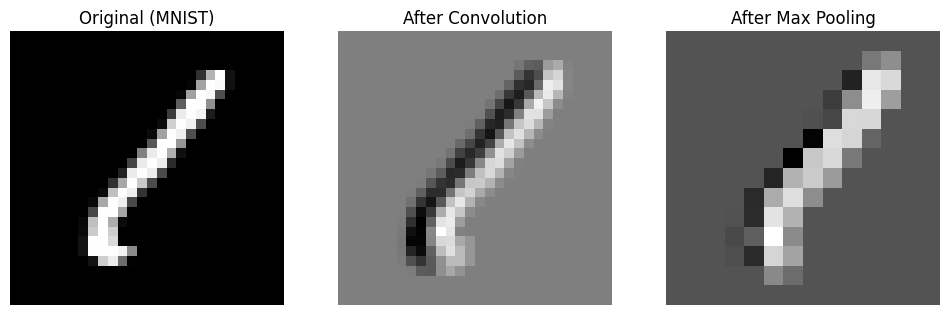

In [8]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = MNIST(root="./data", train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

images, labels = next(iter(loader))
image = images[0, 0].numpy()

kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])
conv_output = convolve2d(image, kernel, mode="same")

pool_size = 2
stride = 2

h, w = conv_output.shape
pooled = np.zeros((h // 2, w // 2))

for i in range(0, h, stride):
    for j in range(0, w, stride):
        region = conv_output[i:i+pool_size, j:j+pool_size]
        if region.shape == (2, 2):
            pooled[i//2, j//2] = np.max(region)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original (MNIST)")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("After Convolution")
plt.imshow(conv_output, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("After Max Pooling")
plt.imshow(pooled, cmap="gray")
plt.axis("off")

plt.show()


**2.2** Определите два фильтра: Sobel X и Edge Detection. Примените оба к картинке через `scipy.signal.convolve2d` с `mode='valid'`. Визуализируйте три картинки рядом: оригинал, результат Sobel X, результат Edge Detection.

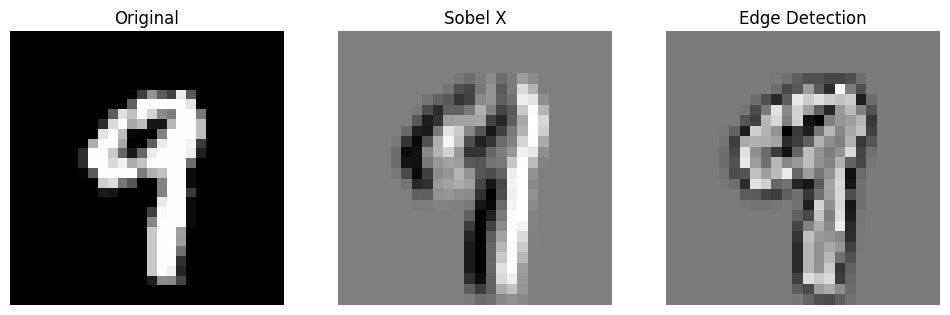

In [9]:
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])


edge = np.array([[-1, -1, -1],
                  [-1,  8, -1],
                  [-1, -1, -1]])

from scipy.signal import convolve2d

images, labels = next(iter(loader))
image = images[0, 0].numpy()

sobel_result = convolve2d(image, sobel_x, mode='valid')
edge_result = convolve2d(image, edge, mode='valid')

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Sobel X")
plt.imshow(sobel_result, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Edge Detection")
plt.imshow(edge_result, cmap="gray")
plt.axis("off")

plt.show()

**2.3** Напишите функцию Max Pooling (size=2, stride=2) и примените к результату свертки Sobel X. Выведите размеры до и после pooling.

Размер после свертки (Sobel X): (26, 26)
Размер после Max Pooling: (13, 13)


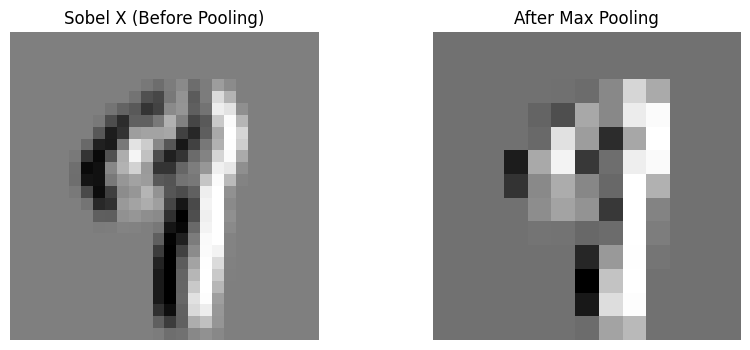

In [10]:
def max_pooling(image, size=2, stride=2):
    h, w = image.shape

    out_h = (h - size) // stride + 1
    out_w = (w - size) // stride + 1

    pooled = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            h_start = i * stride
            w_start = j * stride
            region = image[h_start:h_start + size, w_start:w_start + size]
            pooled[i, j] = np.max(region)

    return pooled

sobel_result = convolve2d(image, sobel_x, mode='valid')

pooled_result = max_pooling(sobel_result, size=2, stride=2)

print("Размер после свертки (Sobel X):", sobel_result.shape)
print("Размер после Max Pooling:", pooled_result.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Sobel X (Before Pooling)")
plt.imshow(sobel_result, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After Max Pooling")
plt.imshow(pooled_result, cmap="gray")
plt.axis("off")

plt.show()

---

## Часть 3 -- Построение CNN в PyTorch

Постройте и обучите сверточную сеть на MNIST.

**3.1** Реализуйте модель `SimpleCNN` со следующей архитектурой:

```
Conv2d(1, 8, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2)
Conv2d(8, 16, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2)
Flatten -> Linear(16*7*7, 10)
```

Проверьте что размеры проходят: подайте `torch.randn(1, 1, 28, 28)` и убедитесь что выход `(1, 10)`.

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.fc = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model = SimpleCNN()

x = torch.randn(1, 1, 28, 28)
y = model(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])


**3.2** Загрузите MNIST, создайте DataLoader (batch_size=64). Обучите модель на 3 эпохи с Adam (lr=0.001) и CrossEntropyLoss. Выведите loss и accuracy после каждой эпохи.

In [16]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.fc = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model = SimpleCNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")


Epoch 1/3 | Loss: 0.3414 | Accuracy: 90.09%
Epoch 2/3 | Loss: 0.0936 | Accuracy: 97.25%
Epoch 3/3 | Loss: 0.0696 | Accuracy: 97.86%


**3.3** Визуализируйте feature maps: прогоните одну картинку через первый сверточный слой и покажите все 8 карт признаков.

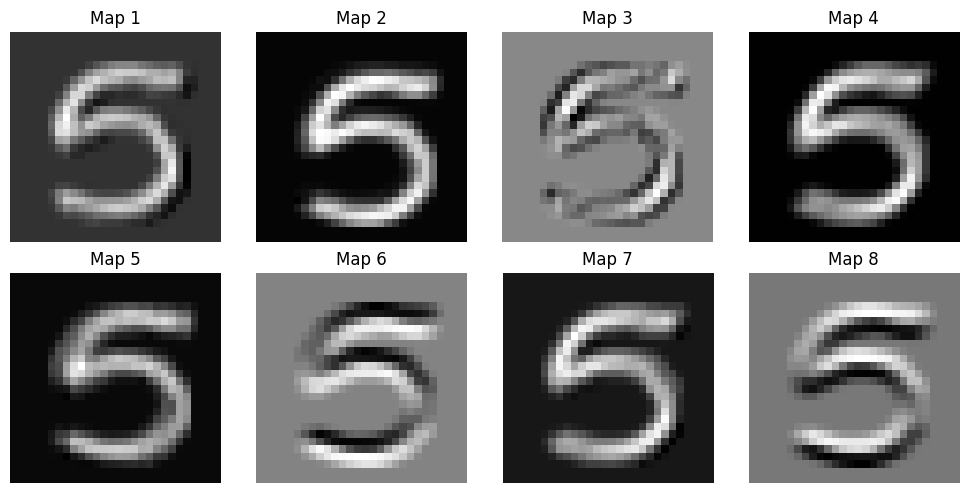

In [17]:
images, labels = next(iter(train_loader))
image = images[0].unsqueeze(0)
model.eval()
with torch.no_grad():
    feature_maps = model.conv1(image)

feature_maps = feature_maps.squeeze(0)

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[i].cpu().numpy(), cmap="gray")
    plt.title(f"Map {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


**3.4** Измените архитектуру: поставьте `kernel_size=5, padding=2` вместо `kernel_size=3, padding=1`. Обучите заново на 3 эпохи. Сравните accuracy с оригинальной моделью.

In [21]:
class SimpleCNN_K5(nn.Module):
    def __init__(self):
        super(SimpleCNN_K5, self).__init__()

        self.conv1 = nn.Conv2d(1, 8, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=5, padding=2)

        self.fc = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model_k5 = SimpleCNN_K5()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_k5.parameters(), lr=0.001)

epochs = 3

for epoch in range(epochs):
    model_k5.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model_k5(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}/3 | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")


Epoch 1/3 | Loss: 0.2736 | Accuracy: 91.77%
Epoch 2/3 | Loss: 0.0777 | Accuracy: 97.61%
Epoch 3/3 | Loss: 0.0569 | Accuracy: 98.22%


---

## Часть 4 -- Объяснение архитектуры

**4.1** Для модели SimpleCNN из части 3.1 напишите: что делает каждый слой, зачем он нужен, и как меняется размер данных. Заполните таблицу:

| Слой | Что делает | Размер до | Размер после |
|------|-----------|-----------|-------------|
| Conv2d(1,8,3,pad=1) | ? | 28x28x1 | ? |
| ReLU | ? | ? | ? |
| MaxPool2d(2) | ? | ? | ? |
| Conv2d(8,16,3,pad=1) | ? | ? | ? |
| ReLU | ? | ? | ? |
| MaxPool2d(2) | ? | ? | ? |
| Flatten | ? | ? | ? |
| Linear(784, 10) | ? | ? | ? |

*Ваш ответ (заполните таблицу):*



---

## Бонус -- Свое изображение

Загрузите любую картинку (фото, скриншот), преобразуйте в черно-белое 28x28, примените свертку и pooling. Визуализируйте результат.

In [ ]:
# Подсказка:
# from PIL import Image
# img = Image.open('your_image.jpg').convert('L').resize((28, 28))
# img_np = np.array(img) / 255.0

# Ваш код здесь
